# Modeling Electric Vehicles (EV)

### Introduction

The objective of this notebook is to simulate the performance of an electric vehicle under three different charging policies. Recall from lecture slides that the energy dynamics of an EV are goverened by the same equation as that of a stationary battery as shown in equation ($1$).

$$ \frac{\text d x(t)}{\text d t} = - \frac{x(t)}{\tau} + p^\text{chem}(t) \tag{1}$$

where $x(t)$ represents the chemical potential energy stored in the battery at time $t$, $\tau$ is the self-dissipation time constant, and $p^\text{chem}(t)$ is the charging/discharging power of the battery at time $t$. This represents a first order linear ODE of the form,

$$\frac{d x(t)}{d t} = Ax(t) + b(t)\tag{2}$$

with a constant coeffiecient $A = -1/\tau$ and a time-varying input $b(t) = p^\text{chem}(t)$. The solution to eq.uation ($2$) with an initial condition $x(t_{init})$ is given by,

$$x(t) = e^{(t-t_{init})A}x(t_{init}) + e^{tA}\int_{t_{init}}^t e^{-\zeta A} b(\zeta) \text d \zeta \tag{3}$$

Using eq. ($3$) the solution to eq.($1$) can be obtained as,

$$ x(t) = x(t_{init}) e^{-(t-t_{init}) / \tau} + e^{-t/\tau}\int_0^t  e^{\zeta/\tau} p^\text{chem}(\zeta) \text d \zeta \tag{4}$$

In order to discretize this equation for numerical simulation, we get,

$$x(t_{k+1}) = e^{-(t_{k+1} - t_k)/\tau}x(t_k) + e^{-t_{k+1}/\tau}\int_{t_k}^{t_{k+1}} e^{\zeta /\tau} p^\text{chem}(\zeta) \text d \zeta \tag{5}$$

Here the value of $A = -1/\tau$ is constant, and the input $b(t) = p^\text{chem}(t)$ is assumed to be piecewise constant over the time interval $[t_k, t_{k+1}]$. Then simpifying the integral in equation ($5$) results in,

$$ x(t_{k+1}) = e^{-(t_{k+1} - t_k)/\tau}x(t_k) + (1-e^{-(t_{k+1} - t_k)/\tau}) \tau p^\text{chem}(t_k) \tag{6}$$

Therefore the discretized form of eq. (1) with a uniform time step $\Delta t$ and a piecewise constant charging and discharging power $p^\text{chem}(t)$ as,

$$ x(k+1) = a x(k) + (1-a) \tau p^\text{chem}(k) \tag{7}$$

where $ a = e^{-\Delta t / \tau}$. The discretization comes about as a result of discretizing a Linear Dynamic System (LDS) discussed in the previous chapter. $x(t)$ is the state variable representing the amoung of chemical energy stored in the battery, and $p^\text{chem}(t)$ is the action variable. By assuming that charging/discharging power is constant within the time period, the integral can be solved to result in equation ($7$).

In this notebook, we shall use equation ($7$) to solve for the state of charge of the EV battery under different charging policies.

### Generating Driving Power

The discharge of an EV battery is a result of driving it. Chemical energy stored in the battery is converted to mechanical energy to drive the vehicle. To simulate the EV performance under various strategies we shall first model the rate of chemical energy discharge due to using the vehicle for trips of different lengths. The chemical rate of chemical energy discharged from the battery due to driving the EV can be expressed as function of energy intensity of the EV ($\alpha$)  in $kWh/km$ and the distance covered ($d$) in $km$ within a given timestep $\Delta t$ as shown in eq. ($8$),

$$ p^\text{chem}(k) = - \frac{\alpha(k) d(k)}{\Delta t} \tag{8}$$

Data from the US Department of Transportation [1] indicates that the one-way trip distance for private vehicles follows a log-normal distribution with a mean of $1.8km$ and a standard deviation of $1.24km$. Furthermore, on any given day, the trip start time for private vehicles follows a uniform distribution from 6:00 to 18:00.

In addition to these, we shall assume the vehicle takes 3 trips per day, a maximum trip distance of $100km$, and a uniform speed of $40km/hr$ for trips with trip distance less than $15km$ and $90km/hr$ for trips longer than $15km$. Time in discretized timesteps will be provided as input and each trip is assumed to at least be the length of one timestep.

A random starttime will be estimated for each daily trip using the unifrom distribution after 6:00, and a random trip distance will be estimated by sampling from the lognormal distribution. Based on the trip distance the speed of the EV will be set as per the condition described previously. Calculating the total trip time based on distance and speed, the power discharge within for that trip at every timestep is calculated using eq ($8$). By performing this calculation for every timestep throughout the total time, the power discharged for each timestep is identified.

In [33]:
import numpy as np


def generate_driving_power(t, alpha):
    """
    generateDrivingPower generates a time series of chemical power discharged
    to drive an electric vehicle.

    Inputs:
        t: the K+1 vector time span in h
        alpha: the K vector energy intensity of driving in kWh/km

    Output:
        p_chem_drive: a K vector of chemical powers discharged to drive in kW
    """
    # timing
    K = len(t) - 1  # number of time steps
    dt = t[1] - t[0]  # time step duration, h
    nd = K * dt / 24  # number of days in time span
    if nd % 1 != 0:
        raise ValueError('The time span must contain an integer number of days.')

    # reshape energy intensity
    alpha = np.reshape(alpha, (int(K / nd), int(nd)))

    # generate discharge powers for driving
    nt = 3  # number of trips per day
    p_chem_drive = np.zeros((int(K / nd), int(nd)))  # chemical discharge powers for driving, kW
    d_trip = np.zeros((nt, int(nd)))  # trip distances, km
    for j in range(int(nd)):  # day index
        for i in range(nt):  # trip index
            # generate trip start time of day
            h_start = 6 + 12 * np.random.rand()  # trip start time of day, h
            k_start = int(h_start // dt)  # trip start time of day index
            while p_chem_drive[k_start, j] > 0:
                h_start = 6 + 12 * np.random.rand()  # trip start time of day, h
                k_start = int(h_start // dt)  # trip start time of day index

            # generate trip distance
            d_trip[i, j] = min(100, np.random.lognormal(1.8, 1.24))  # trip distance, km

            # set trip speed
            if d_trip[i, j] < 15:
                s_trip = 40  # short trip speed, km/h
            else:
                s_trip = 90  # long trip speed, km/h

            # set trip duration
            t_trip = d_trip[i, j] / s_trip  # trip duration, h

            # spread trip discharge energy over the appropriate time steps
            while t_trip > 0:
                p_chem_drive[k_start, j] = alpha[k_start, j] * s_trip * min(dt, t_trip) / dt
                t_trip -= min(dt, t_trip)
                k_start += 1

    # rewrite matrix as stacked vector
    p_chem_drive = p_chem_drive.flatten('F')

    return p_chem_drive

### Simulating Charging Policies

As discussed in the lecture there are three strategies that can be used to charge an EV. An EV can be charged only when it's plugged in. The three policies will first be described in detail and the code to simulate them will be shown.

#### Policy 1

**Policy: When plugged in charge the EV until the battery is full.**

This policy implies that the EV's battery will charge at the maximum possible rate till the charge is full. However, in the last timestep, the maximum charging rate will be higher than the rate required to completely fill the battery. In that situation, the rate will be whatever is required to fill the battery. To express this mathematically we have,

$$
p^\text{chem}(k) = \min \left\{ \eta_c \overline{p}_c , \frac{\overline{x} - a x(k)}{(1 - a) \tau} \right\} \tag{9}$$

where $\eta_c$ is the charging efficiency, $\overline{p}_c$ is the maximum possible electric charging rate, $\overline{x}$ is the maximum possible state of charge, $x(k)$ is the state of charge at timestep $k$, $a$ is the scalar discrete-time dynamics parameter defined as $e^{-\Delta t / \tau}$, and $\tau$ is the time constant of the battery. Using the value of $p^\text{chem}$ obtained from eq. ($9$), the state of the battery at every timestep can be identified using eq. ($7$). Here, the generated discharged chemical power due to driving as starting $p^\text{chem}$. To this the value of charging rate will be added as shown in eqn. ($9$). Therefore, we create a $p^\text{chem}$ array that when positive represents charging and when negative represents discharging. Finally the electric charging power can be obtained from $p^\text{chem}$ by dividing by the charging efficiency $\eta_c$ when the battery is charging i.e., value is positive and multiplying by the discharging efficiency $\eta_d$ when the value is negative.


In [34]:
def simulate_policy1(x0, z, p_chem_drive, a, tau, etac, etad, pc_max, x_max):
    """
    Simulates the first electric vehicle charging policy
    (when plugged in, charge at maximum until full).
    Parameters:
    x0: The battery's initial chemical energy, kWh
    z: A K x 1 of indicators that the vehicle is plugged in
    p_chem_drive:  a K x 1 of chemical powers discharged to drive, kW
    a: A scalar discrete-time dynamics parameter
    tau: The battery's self-dissipation time constant, h
    etac: The battery's charging efficiency
    etad: The battery's discharging efficiency
    pc_max: The battery's maximum charging electrical power, kW
    x_max: The battery's chemical energy capacity, kWh

    Returns:
   x1, a K+1 x 1 vector of stored chemical energies, kWh
   p1, a K x 1 vector of electrical charging powers, kW

    """

    # dimensions
    K = len(z)

    # initialization
    x1 = np.zeros(K + 1) #stored chemical energy, kWh
    x1[0] = x0 #initial state
    p_chem1 = -p_chem_drive #chemical charging power, kW

    # simulation
    for k in range(K):
        # control decision
        if z[k] == 1:  # vehicle is plugged in
            p_chem1[k] = min(etac * pc_max, (x_max - a * x1[k]) / ((1 - a) * tau)) #charge at max til full
        # dynamic update
        x1[k + 1] = a * x1[k] + (1 - a) * tau * p_chem1[k]

    p1 = np.maximum(p_chem1 / etac, etad * p_chem1) #charging electrical power, kW
    p1[z == 0] = 0 #no electrical charging or discharging while unplugged

    return x1, p1

#### Policy 2

**Policy: When the battery charge gets below a certain threshold charge at maximum possible until full.**

This policy builds on what Policy 1 already does by adding in an additional constraint. In Policy 1 the battery is charged at maximum as soon as it plugged in irrespective of the current level of charge. In Policy 2, an additional constraint is added by charging the battery when its plugged in and when the state of charge is below a threshold. To identify the charging and discharging value at each timestep in this case, first we shall define an indicator variable $y(k)$ that will have a value of 1 when the battery is charging and 0 otherwise. So whenever the value of $y(k)$ the battery is charging at the maximum possible charging rate. This rate is the same as the one described by eq. ($9$).

In Policy 1, the value of $y(k)$ whenever the vehicle is plugged in i.e., $z(k) = 1$. Here, the additional constraint should be added to this so,

$$y(k) = \begin{cases}
  1 & \text{if } z(k)=1 \text{ and } x(k)<\underline{x} \\
  0 & \text{if } z(k) = 0 \text{ or } x(k) = \overline{x}
\end{cases}\tag{10}$$

In [35]:
import numpy as np

def simulate_policy2(x0, z, p_chem_drive, a, tau, etac, etad, pc_max, x_max, x_min):
    """
    simulatePolicy2 simulates the second electric vehicle charging policy
    (when plugged in and below minimum charge, charge at maximum until full).

    Inputs:
      x0, the battery's initial chemical energy, kWh
      z, a K x 1 of indicators that the vehicle is plugged in
      pChemDrive, a K x 1 of chemical powers discharged to drive, kW
      a, a scalar discrete-time dynamics parameter
      tau, the battery's self-dissipation time constant, h
      etac, the battery's charging efficiency
      etad, the battery's discharging efficiency
      pcMax, the battery's maximum charging electrical power, kW
      xMax, the battery's chemical energy capacity, kWh
      xMin, the minimum acceptable chemical energy, kWh

    Returns :
      x2, a K+1 x 1 vector of stored chemical energies, kWh
      p2, a K x 1 vector of electrical charging powers, kW
    """

    # dimensions
    K = len(z)

    # Initialization
    x2 = np.zeros(K + 1) # stored chemical energy, kWh
    x2[0] = x0 #initial state
    p_chem2 = -p_chem_drive # chemical charging power, kW
    y2 = np.zeros(K)  # Indicator for charging mode

    # Simulation
    for k in range(K):
        # control decision
        if k >= 1:
            y2[k] = y2[k - 1]   # initialize charge mode with previous charge mode

        # Control decision logic
        if z[k] == 0 or x2[k] == x_max:  #  vehicle is unplugged or battery is full
            y2[k] = 0  # charge mode off
        elif z[k] == 1 and x2[k] < x_min:  # vehicle is plugged in and battery is nearly empty
            y2[k] = 1  # charge mode on

        if y2[k] == 1: # vehicle is in charging mode
            p_chem2[k] = min(etac * pc_max, (x_max - a * x2[k]) / ((1 - a) * tau))

        # dynamic update
        x2[k + 1] = a * x2[k] + (1 - a) * tau * p_chem2[k]

    p2 = np.maximum(p_chem2 / etac, etad * p_chem2) # charging electrical power, kW

    p2[z == 0] = 0  # no electrical charging or discharging while unplugged

    return x2, p2


#### Policy 3

**Policy 3: When the battery charge gets below a certain threshold, charge steadily to meet a given deadline.**

Policy 2 charges the battery at the maximum possible rate to until the battery is full. Policy 3 builds on Policy 2 by charging steadily to meet a set deadline. So, if the user wants their battery to be charged to given extent $x^*$ by a given timestep $k^*$, Policy 3 would be used. In this case the charging rate will not be the maximum possible but instead will be a uniform value that will satisfy the given constraint. So in addition to the indicator variable to indicate if the charge is below minimum value, a new charging scheme must be defined so that the charging rate is constant and meets the deadline. The charging rate can be defined as follows,

$$ p^\text{chem}(k) = \min \left\{ \eta_c \overline{p_c}, \frac{ x^\star - a^{k^\star - k} x(k) }{ (1 + a + \dots + a^{k^\star - k - 1}) (1-a)  \tau } \right\}\tag{11}$$

In [36]:

def simulate_policy3(x0, z, p_chem_drive, a, tau, etac, etad, pc_max, x_max, x_min, t, h_deadline, x_star):
    """
    simulatePolicy3 simulates the third electric vehicle charging policy
    (when plugged in and below minimum charge, charge just fast enough to
    meet a deadline).

    Inputs:
        x0: the battery's initial chemical energy, kWh
        z: a K x 1 array of indicators that the vehicle is plugged in
        p_chem_drive: a K x 1 array of chemical powers discharged to drive, kW
        a: a scalar discrete-time dynamics parameter
        tau: the battery's self-dissipation time constant, h
        etac: the battery's charging efficiency
        etad: the battery's discharging efficiency
        pc_max: the battery's maximum charging electrical power, kW
        x_max: the battery's chemical energy capacity, kWh
        x_min: the minimum acceptable chemical energy, kWh
        t: the simulation time span, h
        h_deadline: the hour of day of the charging deadline (0 = midnight)
        x_star: the desired charge at the deadline, kWh

    Outputs:
        x3: a K+1 x 1 vector of stored chemical energies, kWh
        p3: a K x 1 vector of electrical charging powers, kW
    """
    # timing
    K = len(z)  # number of time steps
    dt = t[1] - t[0]  # time step duration, h

    # data storage
    x3 = np.zeros(K + 1)  # stored chemical energy, kWh
    x3[0] = x0  # initial state
    p_chem3 = -p_chem_drive  # chemical charging power, kW
    y3 = np.zeros(K)  # indicator of charging mode

    # simulation
    for k in range(K):
        # control decision
        if k > 0:
            y3[k] = y3[k - 1]  # initialize charge mode with previous charge mode
        if z[k] == 0 or x3[k] == x_max:  # vehicle is unplugged or battery is full
            y3[k] = 0  # charge mode off
        if z[k] == 1 and x3[k] < x_min:  # vehicle is plugged in and battery is nearly empty
            y3[k] = 1  # charge mode on
        if y3[k] == 1:  # vehicle is in charging mode
            k_star_indices = np.where((np.abs(np.mod(t, 24) - h_deadline) < dt / 2) & (t > t[k]))[0]
            k_star = k_star_indices[0] if k_star_indices.size > 0 else None
            if k_star is None:  # deadline exceeds last time step
                k_star_indices = np.where((np.abs(np.mod(t, 24) - h_deadline) < dt / 2) & (t <= t[k]))[0]
                k_star = round(24 / dt) + k_star_indices[-1]
            p_chem3[k] = min(etac * pc_max, (x_star - a ** (k_star - k) * x3[k]) /
                             (sum(a ** np.arange(0, k_star - k)) * (1 - a) * tau))

        # dynamic update
        x3[k + 1] = a * x3[k] + (1 - a) * tau * p_chem3[k]

    p3 = np.maximum(p_chem3 / etac, etad * p_chem3)  # charging electrical power, kW
    p3[z == 0] = 0  # no electrical charging or discharging while unplugged

    return x3, p3


### Analysis

Now that all three policies have been descirbed in detail along with the equations used to simulate them, we can implement them in code and analyze their performance. Let us first import the required libraries and set some plotting parameters.

In [37]:
# ==============================================================================
# Required imports
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt


# ==============================================================================
# Graphics settings
# ==============================================================================
plt.rc('font', size=15)
plt.rc('axes', titlesize=20, labelsize=20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=20)
plt.rc('lines', linewidth=3)


Consider a battery with the following parameters:
- Maximum state of charge, $\overline{x} = 80 kWh$
- Minimum state of charge, $\underline{x} = 0.5\overline{x} = 40 kWh$
- Maximum charging power, $\overline{p_c} = 11.5 kW$
- Charging efficiency, $\eta_c = 0.95$
- Discharging efficiency, $\eta_d = 0.95$
- Self-dissipation time constant, $\tau = 1600hrs$
- Energy intensity of the EV, $\alpha = 0.3 kWh/km$
- Total simulation time, $t = 7 days$
- Simulation Timestep , $\Delta t = 1 hr$

The battery is assumed to be plugged in from 18:00 to 6:00 in the morning. The discharging power due to driving is generated as per the method described previously.

In [38]:
# timing
t0 = 0  # initial time, h
nd = 7  # number of days in time span
tf = t0 + 24 * nd  # final time, h
dt = 1/60  # time step duration, h
t = np.linspace(t0, tf, int((tf - t0) / dt) + 1)  # time span, h
K = len(t) - 1  # number of time steps

# EV parameters
tau = 1600  # self-dissipation time constant, h
a = np.exp(-dt/tau)  # discrete-time dynamics parameter
etac = 0.95  # charging efficiency
etad = etac  # discharging efficiency
pc_max = 11.5  # charging capacity, kW
pd_max = 0  # discharging capacity, kW
x_max = 80  # energy capacity, kWh
x0 = x_max  # initial energy, kWh
x_min = 0.5 * x_max  # minimum acceptable energy capacity, kWh
alph = 0.3 * np.ones(K)  # energy intensity of driving, kWh/km

# generate discharge powers for driving
pChemDrive = generate_driving_power(t, alph)  # chemical power discharged to drive EV, kW

# plugged-in hours
z = np.zeros(K)  # indicator that vehicle is plugged in
z[np.mod(t[:K], 24) < 6] = 1  # plug in overnight
z[np.mod(t[:K], 24) > 18] = 1  # plug in overnight
z[pChemDrive > 0] = 0  # unplug if vehicle is driving

# electricity price indicator
w = np.zeros(K)  # electricity price indicator (0 = off-peak, 1 = on-peak)
w[(np.mod(t[:K], 24) >= 14) & (np.mod(t[:K], 24) < 22)] = 1  # on-peak from 5pm to 11pm

First, let us plot the generated discharging power profile due to driving the EV over the total simulation time.

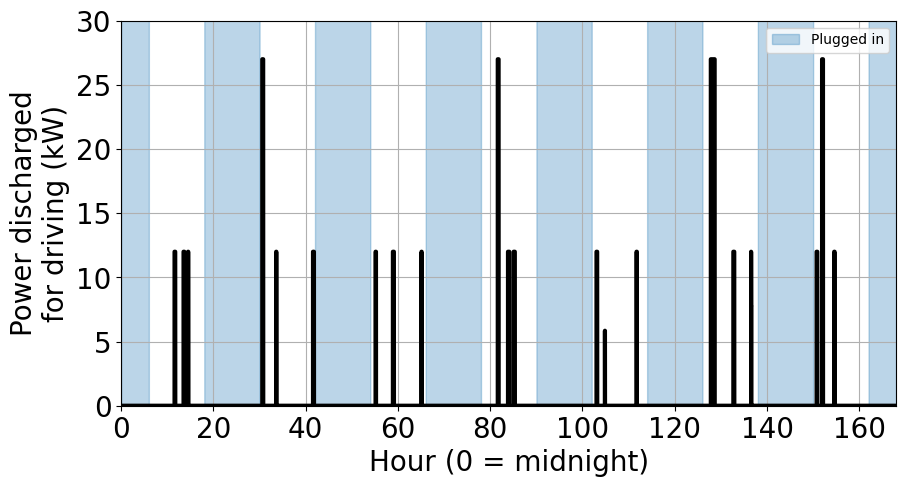

<Figure size 640x480 with 0 Axes>

In [39]:
# input signal plot
t_lim = [t0, tf]  # time axis limits, h
e_lim = [0, x_max]  # energy axis limits, kWh
p_lim = [0, pc_max]  # electric power axis limits, kW
pChemLim = [0, np.ceil(np.max(pChemDrive) / 5) * 5]  # chemical power axis limits, kW

def full_stairs(tspan, u, **kwargs):
    u = np.append(u, u[-1])
    plt.step(tspan, u, where='post', **kwargs)

# driving power plot with plugged-in periods shaded
plt.figure(figsize=(10, 5))
plt.fill_between(t[:K], max(pChemLim) * z, color='tab:blue',alpha=0.3, step='post', label='Plugged in')

full_stairs(t, pChemDrive, color='k')
plt.xlim(t_lim)
plt.ylim(pChemLim)
plt.ylabel('Power discharged\nfor driving (kW)')
plt.xlabel('Hour (0 = midnight)')
plt.grid()
plt.legend()
plt.show()
plt.tight_layout()

Before running the simulation for the three policies, we shall define a function to plot the EV performance including the state of charge, charging power, and discharging power.

In [40]:
import matplotlib.pyplot as plt

def plot_ev_results(t, x, p, z, w, x_max, x_min, pc_max, fig_num):
    """
    plotEVresults plots electric vehicle simulation results.

    Inputs:
        t: a K+1 vector time span in h
        x: a K+1 vector of stored energies in kWh
        p: a K vector of charging powers in kW
        z: a K vector of indicator variables that the vehicle is plugged in
        x_max: the battery capacity in kWh
        x_min: the minimum acceptable stored energy in kWh
        pc_max: the electric charging power capacity in kW
        fig_num: the figure number to plot into
    """
    # parameters
    K = len(t) - 1  # number of time steps
    t_lim = [t[0], t[-1]]  # time axis limits, h

    # energy plot
    plt.figure(fig_num, figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.step(t, x, where='post', color='k', linewidth=1.5)  # Proper step plot
    plt.xlim(t_lim)
    plt.ylim([0, x_max])
    plt.ylabel('Stored\nenergy (kWh)')
    plt.axhline(y=x_min, color='m', linestyle='--', label='Minimum energy ($x_{min}$)')
    plt.text(np.mean(t_lim) / 4, x_min, '$x_{min}$', color='m',
             horizontalalignment='left', verticalalignment='top')
    plt.legend()
    plt.grid(True, linestyle='--')

    # charging power plot
    plt.subplot(2, 1, 2)
    plt.fill_between(t[:-1], 0, pc_max * z, color='tab:blue', alpha=0.3, step='post', label='Plugged in')
    plt.fill_between(t[:-1], 0, pc_max * w, color='yellow', alpha=0.3, step='post', label='On-peak')
    plt.step(t[:-1], p, where='post', color='k', linewidth=1.5)
    plt.xlim(t_lim)
    plt.ylim([0, pc_max + 0.1])
    plt.ylabel('Charging\npower (kW)')
    plt.xlabel('Hour (0 = midnight)')
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.legend()
    plt.show()


Now let us simulate the three policies one by one. For Policy 1, the battery is charged at maximum possible rate whenever it is plugged in.

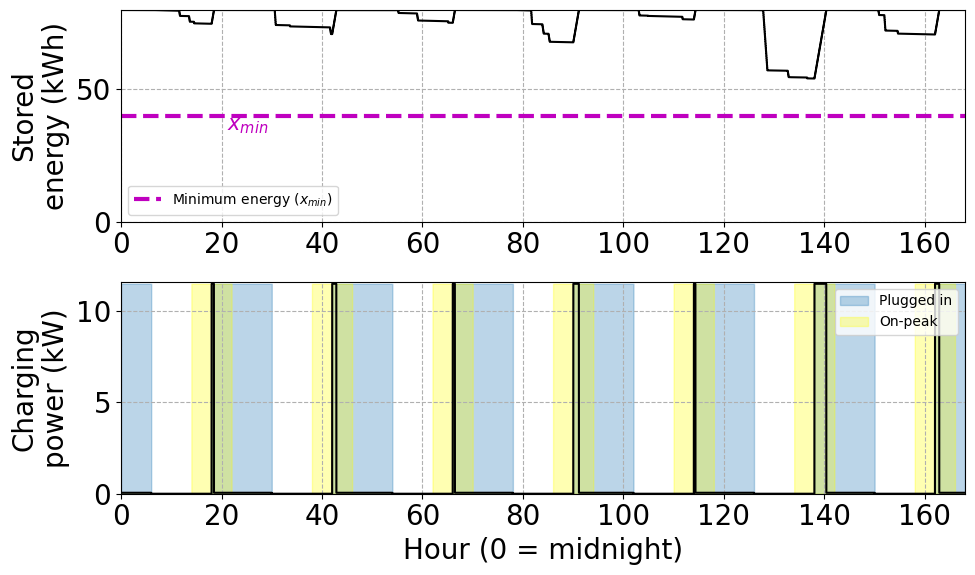

In [41]:
# policy 1: when plugged in, charge at maximum until full
# simulation
x1, p1 = simulate_policy1(x0, z, pChemDrive, a, tau, etac, etad, pc_max, x_max)

# plot simulation results
plot_ev_results(t, x1, p1, z, w, x_max, x_min, pc_max, 2)

For Policy 2, the battery is charged at maximum possible rate whenever it is plugged in and the state of charge is below $40kWh$.

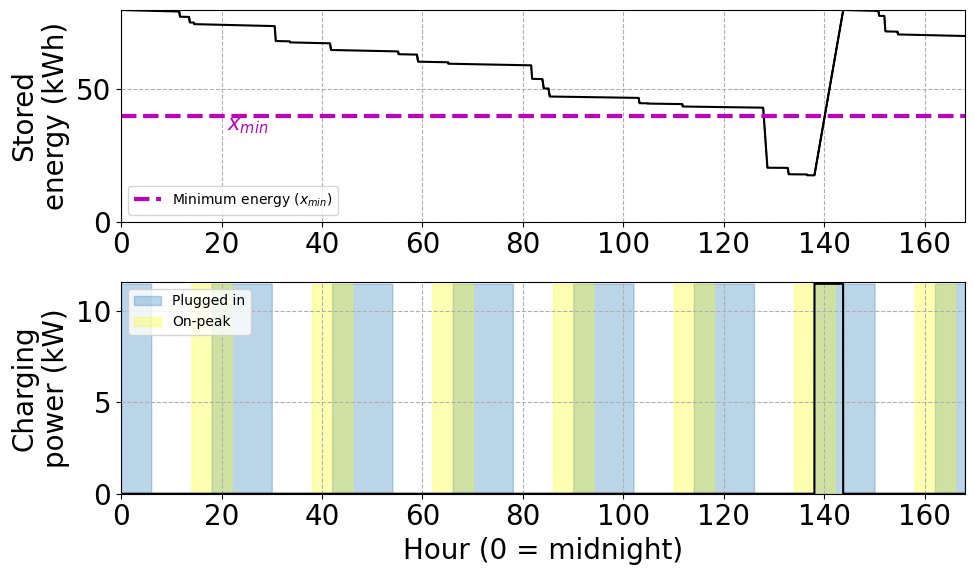

In [42]:
# policy 2: when energy gets low, charge at maximum until full
# simulation
x2, p2 = simulate_policy2(x0, z, pChemDrive, a, tau, etac, etad, pc_max, x_max, x_min)

# plot simulation results
plot_ev_results(t, x2, p2, z, w, x_max, x_min, pc_max, 3)


For Policy 3, the battery is charged steadily to meet a deadline whenever it is plugged in and the state of charge is below the minimum threshold. Here the deadline is set to be the end of plugged in time i.e., 6:00 in the morning. The target state of charge at the deadline is set to be the maximum value of capacity of the battery, $80kWh$.

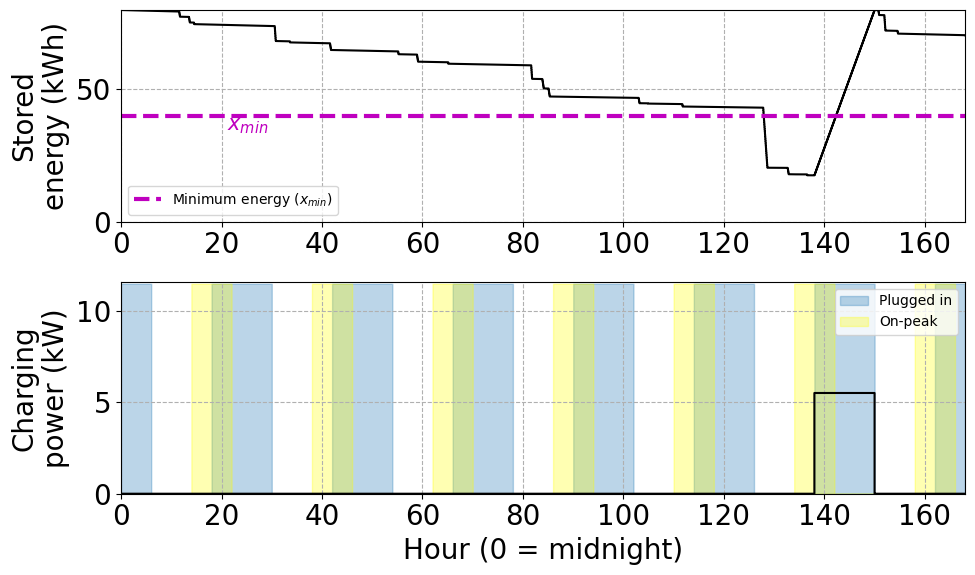

In [43]:
# policy 3: when energy gets low, charge at constant power to meet deadline
# parameters
h_deadline = 6  # hour of day of charging deadline, h
x_star = x_max  # charging target, kWh
# simulation
x31, p31 = simulate_policy3(x0, z, pChemDrive, a, tau, etac, etad, pc_max, x_max, x_min, t, h_deadline, x_star)

# plot simulation results
plot_ev_results(t, x31, p31, z, w, x_max, x_min, pc_max, 4)


### References

[1] US DOT (2017), National Household Travel Survey